# 0. Notebook Setup

In [1]:
!pip install albumentations timm --quiet

In [2]:
import os, cv2, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision.models import resnet50, ResNet50_Weights

import albumentations as A
from albumentations.pytorch import ToTensorV2

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# 1. Dataset Loader

In [3]:
DATA_DIR = "/kaggle/input/datasets/saifewu/py-crackdb/Classification"

images, labels = [], []

for label, folder in enumerate(["Without crack", "With crack"]):
    path = os.path.join(DATA_DIR, folder)
    for file in os.listdir(path):
        images.append(os.path.join(path, file))
        labels.append(label)

df = pd.DataFrame({"image": images, "label": labels})
print(df["label"].value_counts())
df.head()

label
1    369
0    200
Name: count, dtype: int64


,image,label
0,/kaggle/input/datasets/saifewu/py-crackdb/Clas...,0
1,/kaggle/input/datasets/saifewu/py-crackdb/Clas...,0
2,/kaggle/input/datasets/saifewu/py-crackdb/Clas...,0
3,/kaggle/input/datasets/saifewu/py-crackdb/Clas...,0
4,/kaggle/input/datasets/saifewu/py-crackdb/Clas...,0


# 2. Train-Test Split

In [4]:
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=SEED
)

print("Train:", len(train_df), "Val:", len(val_df))

Train: 455 Val: 114


# 3. Augmentation

In [5]:
train_tf = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.85, 1.0)),

    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5),

    A.OneOf([
        A.GaussNoise(std_range=(0.01, 0.05)),
        A.GaussianBlur(blur_limit=3)
    ], p=0.3),

    A.ColorJitter(
        brightness=0.2, contrast=0.2,
        saturation=0.15, hue=0.05, p=0.5
    ),

    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])

# 4. Custom Dataset

In [6]:
class CrackDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = cv2.imread(row["image"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = self.transform(image=image)["image"]
        label = torch.tensor(row["label"], dtype=torch.long)

        return image, label

# 5. DataLoaders

In [7]:
train_loader = DataLoader(
    CrackDataset(train_df, train_tf),
    batch_size=32, shuffle=True
)

val_loader = DataLoader(
    CrackDataset(val_df, val_tf),
    batch_size=32, shuffle=False
)

# 6. Model

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = resnet50(weights=ResNet50_Weights.DEFAULT)

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 2)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 215MB/s]


# 7. Training Setup

In [9]:
class_weights = torch.tensor([1.8, 1.0]).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# 8. Training Loop

In [10]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# 9. Validation

In [11]:
def evaluate(model, loader):
    model.eval()
    preds, targets, probs = [], [], []
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)
            total_loss += loss.item()

            prob = torch.softmax(outputs, dim=1)[:,1].cpu().numpy()
            pred = torch.argmax(outputs, dim=1).cpu().numpy()

            preds.extend(pred)
            targets.extend(labels.cpu().numpy())
            probs.extend(prob)

    acc = accuracy_score(targets, preds)
    f1 = f1_score(targets, preds)
    auc = roc_auc_score(targets, probs)
    cm = confusion_matrix(targets, preds)

    avg_loss = total_loss / len(loader)

    return avg_loss, acc, f1, auc, cm

# 10. Run Training

In [12]:
train_losses = []
val_losses = []
val_accs = []
val_f1s = []

In [13]:
best_acc = 0
patience = 5
counter = 0

EPOCHS = 25

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_loss, acc, f1, auc, cm = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(acc)
    val_f1s.append(f1)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")
    print("Confusion Matrix:\n", cm)

    if acc > best_acc:
        best_acc = acc
        counter = 0

        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")

    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered at epoch:", epoch+1)
        break


Epoch 1
Train Loss: 0.5593 | Val Loss: 0.3661
Acc: 0.9035 | F1: 0.9308 | AUC: 0.9970
Confusion Matrix:
 [[29 11]
 [ 0 74]]

Epoch 2
Train Loss: 0.2637 | Val Loss: 0.1054
Acc: 0.9912 | F1: 0.9933 | AUC: 1.0000
Confusion Matrix:
 [[39  1]
 [ 0 74]]

Epoch 3
Train Loss: 0.0942 | Val Loss: 0.0373
Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000
Confusion Matrix:
 [[40  0]
 [ 0 74]]

Epoch 4
Train Loss: 0.0390 | Val Loss: 0.0151
Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000
Confusion Matrix:
 [[40  0]
 [ 0 74]]

Epoch 5
Train Loss: 0.0196 | Val Loss: 0.0084
Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000
Confusion Matrix:
 [[40  0]
 [ 0 74]]

Epoch 6
Train Loss: 0.0153 | Val Loss: 0.0037
Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000
Confusion Matrix:
 [[40  0]
 [ 0 74]]

Epoch 7
Train Loss: 0.0123 | Val Loss: 0.0037
Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000
Confusion Matrix:
 [[40  0]
 [ 0 74]]

Epoch 8
Train Loss: 0.0058 | Val Loss: 0.0037
Acc: 1.0000 | F1: 1.0000 | AUC: 1.0000
Confusion Matrix:
 [[40  0]
 [ 0 74]]
Early st

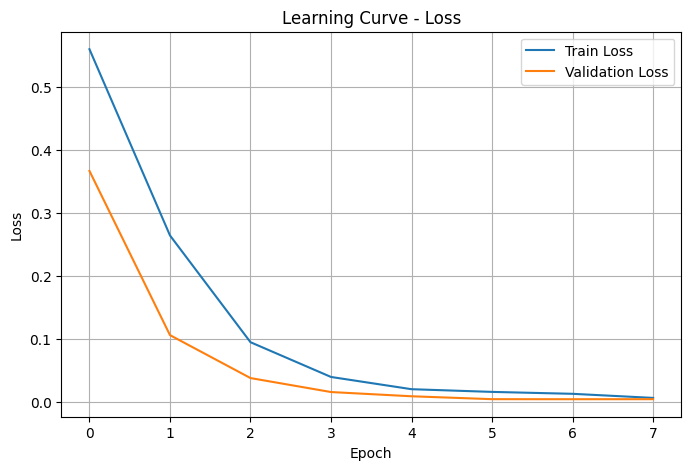

In [14]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve - Loss")
plt.legend()
plt.grid()
plt.show()

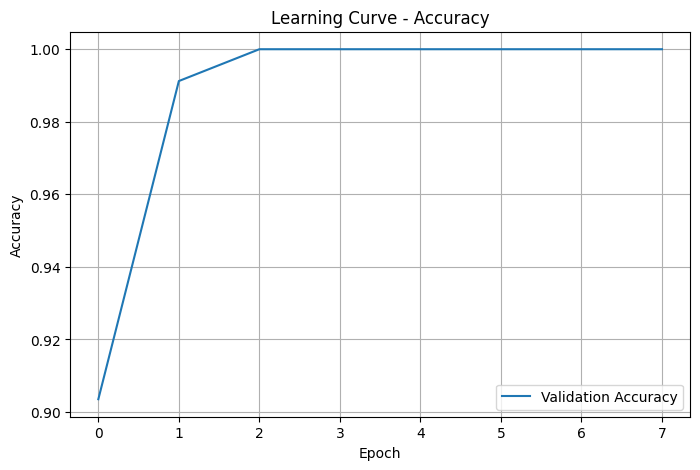

In [15]:
plt.figure(figsize=(8,5))
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Accuracy")
plt.legend()
plt.grid()
plt.show()

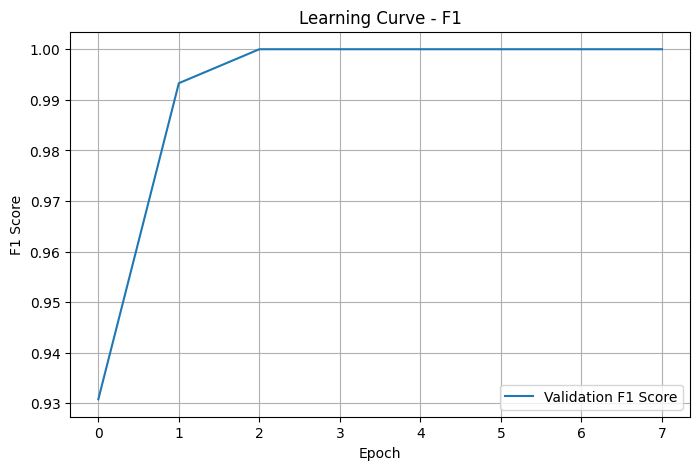

In [16]:
plt.figure(figsize=(8,5))
plt.plot(val_f1s, label="Validation F1 Score")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Learning Curve - F1")
plt.legend()
plt.grid()
plt.show()

In [17]:
best_epoch = np.argmax(val_accs)
print("Best Epoch:", best_epoch + 1)

Best Epoch: 3


# 11. Augmentation Visualization

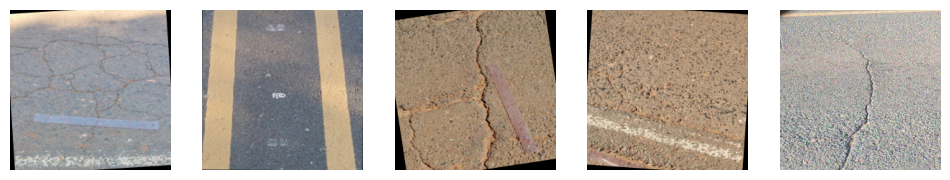

In [18]:
def denormalize(x):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    x = x * std + mean
    return np.clip(x, 0, 1)

def show_augmented(df, transform):
    plt.figure(figsize=(12,4))
    for i in range(5):
        img = cv2.imread(df.iloc[i]["image"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        aug = transform(image=img)["image"].permute(1,2,0).numpy()
        aug = denormalize(aug)

        plt.subplot(1,5,i+1)
        plt.imshow(aug)
        plt.axis("off")
    plt.show()

show_augmented(train_df, train_tf)

# 12. Save Model

In [19]:
torch.save(model.state_dict(), "/kaggle/working/resnet50_crack_Aplus.pth")